In [33]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits
from IPython.display import display, HTML
import matplotlib.colors as colors
import matplotlib
display(HTML("<style>.container { width:95% !important; }</style>"))

font = {'size'   : 14}

matplotlib.rc('font', **font)

import matplotlib.patches as patches
from copy import copy

In [2]:
cube = fits.open("/home/milic/data/scratch/sr_inverted.fits")[0].data

In [3]:
cube.shape

(146, 116, 129, 9)

In [4]:
I = cube[:,:,:,7] + cube[:,:,:,8]
I.shape

(146, 116, 129)

In [5]:
Bh = cube[:,:,:,0] * np.sin(cube[:,:,:,1])
Bz = cube[:,:,:,0] * np.cos(cube[:,:,:,1])

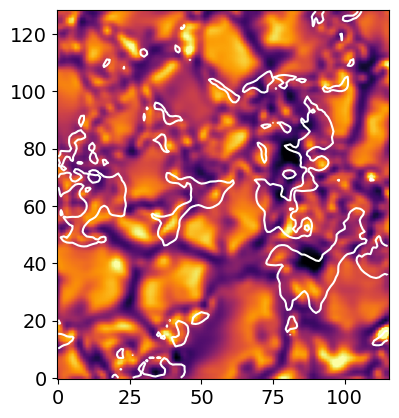

In [6]:
t = 20
plt.imshow(I[t].T, origin='lower', cmap='inferno', vmin=0.7,vmax=1.3)
plt.contour(Bh[t].T, [500],colors='white')

In [7]:
Bx = Bh * np.cos(cube[:,:,:,2])

In [8]:
By = Bh * np.sin(cube[:,:,:,2])

In [9]:
Bxa = Bx[:, ::2, ::2]
Bya = By[:,::2,::2]

In [10]:
x = np.arange(Bxa.shape[1])*2.0
y = np.arange(Bya.shape[2])*2.0

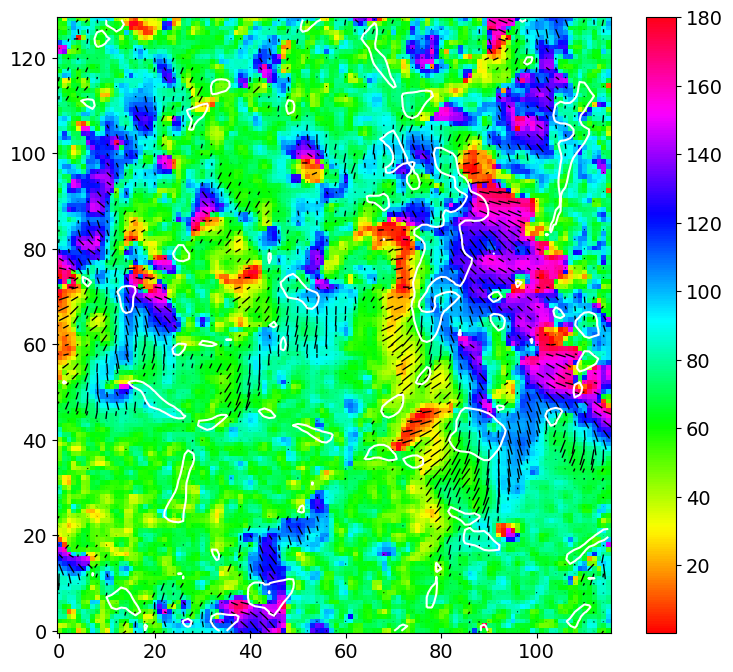

In [12]:
plt.figure(figsize=[9,8])
plt.imshow(np.degrees(cube[t,:,:,2].T), origin='lower', cmap='hsv')
plt.colorbar()
plt.quiver(X, Y, -Bxa[t].T, -Bya[t].T, scale=20000, headwidth=0)
plt.contour(I[t].T, [0.84], colors='white')

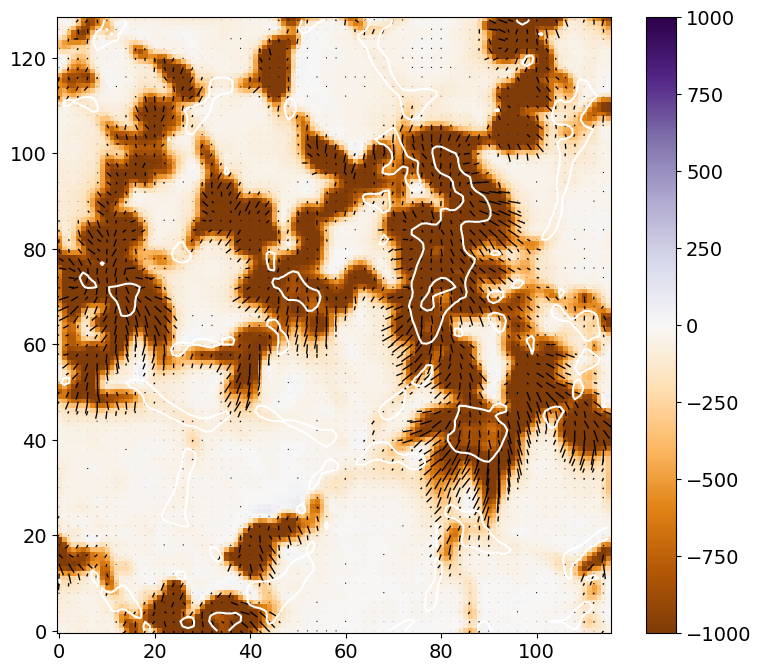

In [12]:
plt.figure(figsize=[9,8])
plt.imshow((Bz[t].T), origin='lower', cmap='PuOr', vmin=-1000, vmax=1000)
plt.colorbar()
plt.quiver(X, Y, -Bxa[t].T, -Bya[t].T, scale=20000, headwidth=0)
plt.contour(I[t].T, [0.86], colors='white')

In [13]:
#![image.png](attachment:5c764323-7a8f-494a-9e24-a4d19111d074.png)

In [14]:
Bxar = Bxa * np.cos(np.radians(15)) - Bya * np.sin(np.radians(15))
Byar = Bya * np.cos(np.radians(15)) + Bxa * np.sin(np.radians(15))

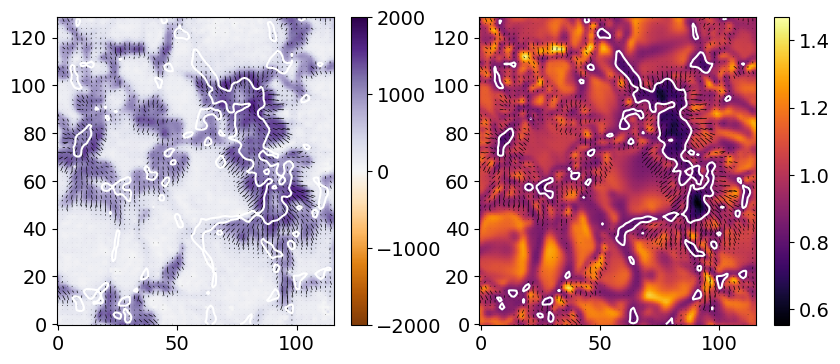

In [15]:
t = 90
plt.figure(figsize=[10,4])
plt.subplot(121)
#plt.imshow((Bz[t].T), origin='lower', cmap='PuOr', vmin=-1500, vmax=1500)
plt.imshow((cube[t,:,:,0].T), origin='lower', cmap='PuOr', vmin=-2000, vmax=2000)
plt.colorbar()
plt.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=20000, headwidth=0)
plt.contour(I[t].T, [0.86], colors='white')
plt.subplot(122)
plt.imshow((I[t].T), origin='lower', cmap='inferno')
plt.colorbar()
plt.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=20000, headwidth=0)
plt.contour(I[t].T, [0.84], colors='white')
plt.savefig("bh_lines.png", bbox_inches='tight')

In [16]:
NX = cube.shape[1]
NY = cube.shape[2]
x = np.arange(NX) * 48.0 # km
y = np.arange(NY) * 48.0 # km
print (NX, NY)

xa = np.arange(NX) * 0.065
ya = np.arange(NY) * 0.065

116 129


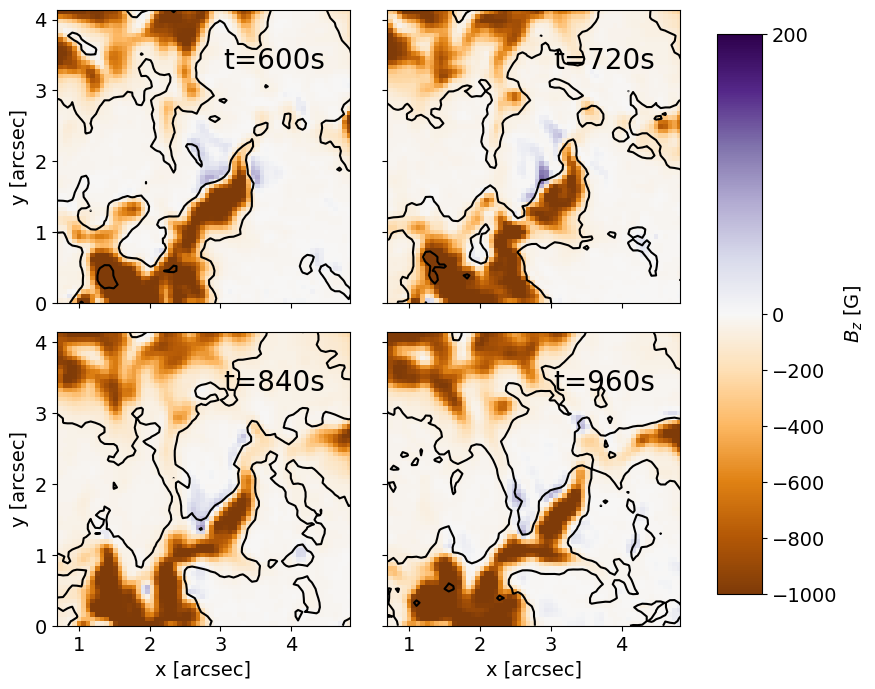

In [17]:
t0 = 60
t = 60
dt = 12
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[9,8])


divnorm = colors.TwoSlopeNorm(vmin=-1000, vcenter=0, vmax=200)

#subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(wspace=-0.1, hspace=0.1)
for ax in axes.flat:
    im = ax.imshow((Bz[t].T), origin='lower', cmap='PuOr', norm=divnorm, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
    #ax.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=10000, headwidth=0)
    ax.contour(xa, ya, Bh[t].T, [200], colors='black')
    ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
    ax.set_xlim([500/725.0,3500/725.0])
    ax.set_ylim([0/725.0,3000/725.0])
    
    if (t==t0):
        ax.set_xticklabels([])
        ax.set_ylabel("y [arcsec]")
    
    if (t==t0+dt):
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        
    if (t==t0+2*dt):
        ax.set_xlabel("x [arcsec]")
        ax.set_ylabel("y [arcsec]")
    if (t==t0+3*dt):
        ax.set_yticklabels([])
        ax.set_xlabel("x [arcsec]")
    
    t += dt

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.9, 0.15, 0.05, 0.7])
#fig.subplots_adjust(top=0.95)
#cbar_ax = fig.add_axes([0.15, 0.92, 0.7, 0.05])

cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('$B_z$ [G]')

plt.savefig("zoom_in_evolution_2min.eps",bbox_inches='tight')
plt.savefig("zoom_in_evolution_2min.png",bbox_inches='tight')

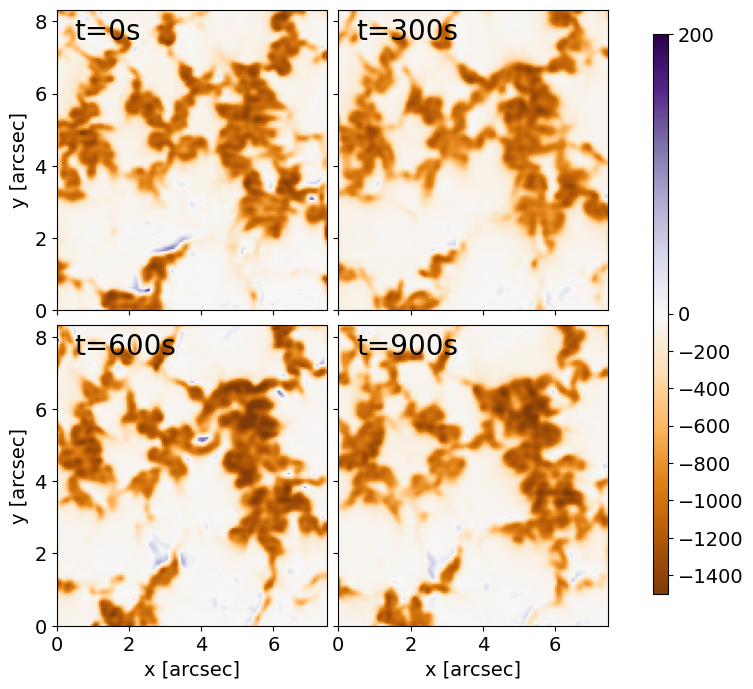

In [18]:
t0 = 0
t = t0
step = 30

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[7.5,8])


divnorm = colors.TwoSlopeNorm(vmin=-1500, vcenter=0, vmax=200)

#subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

fig.subplots_adjust(wspace=-0.2, hspace=0.05)

for ax in axes.flat:
    im = ax.imshow((Bz[t].T), origin='lower', cmap='PuOr', norm=divnorm, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
    #ax.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=10000, headwidth=0)
    #ax.contour(xa, ya, Bh[t].T, [200], colors='black')
    ax.text(0.5,7.5, "t="+str(t*10)+"s", color='black', fontsize=20)
    #ax.set_xlim([500/725.0,3500/725.0])
    #ax.set_ylim([0/725.0,3000/725.0])
    
    if (t==t0):
        ax.set_xticklabels([])
        ax.set_ylabel("y [arcsec]")
    
    if (t==t0+step):
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        
    if (t==t0+2*step):
        ax.set_xlabel("x [arcsec]")
        ax.set_ylabel("y [arcsec]")
    if (t==t0+3*step):
        ax.set_yticklabels([])
        ax.set_xlabel("x [arcsec]")
        
    t += step
    

fig.subplots_adjust(right=0.97)
cbar_ax = fig.add_axes([0.975, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.savefig("evolution_5min.eps",bbox_inches='tight')
plt.savefig("evolution_5min.png",bbox_inches='tight')

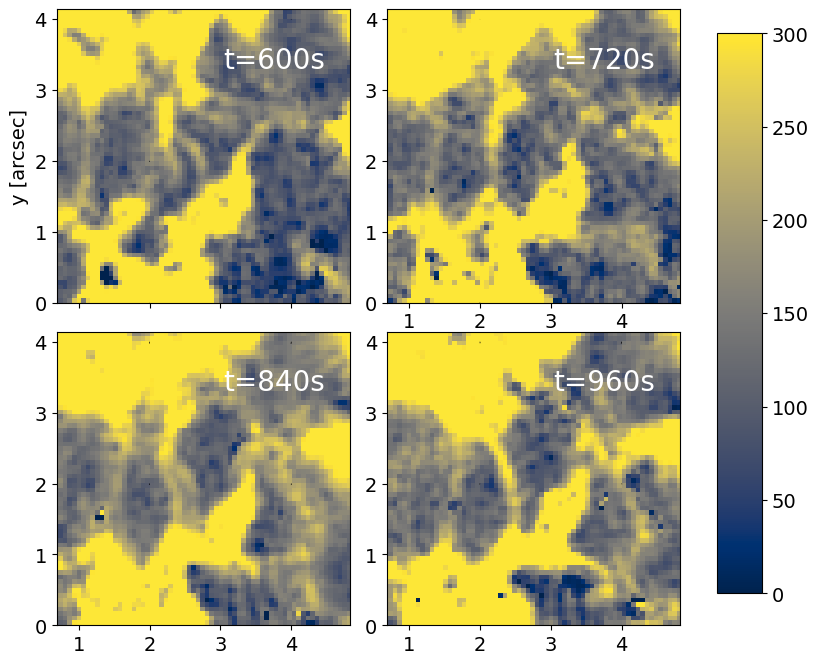

In [19]:
t = 60
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[9,8])


#divnorm = colors.TwoSlopeNorm(vmin=0, vcenter=0, vmax=300)

#subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(wspace=-0.1, hspace=0.1)
for ax in axes.flat:
    im = ax.imshow((Bh[t].T), origin='lower', cmap='cividis', vmin=0, vmax=300, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
    ax.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=10000, headwidth=0)
    ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='white', fontsize=20)
    ax.set_xlim([500/725.0,3500/725.0])
    ax.set_ylim([0/725.0,3000/725.0])
    
    if (t==60):
        ax.set_xticklabels([])
        ax.set_ylabel("y [arcsec]")
    
    if (t==63):
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        
    if (t==66):
        ax.set_xlabel("x [arcsec]")
        ax.set_ylabel("y [arcsec]")
    if (t==69):
        ax.set_yticklabels([])
        ax.set_xlabel("x [arcsec]")
    
    t += 12

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.9, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.savefig("zoom_in_evolution_2min_h.eps",bbox_inches='tight')
plt.savefig("zoom_in_evolution_2min_h.png",bbox_inches='tight')

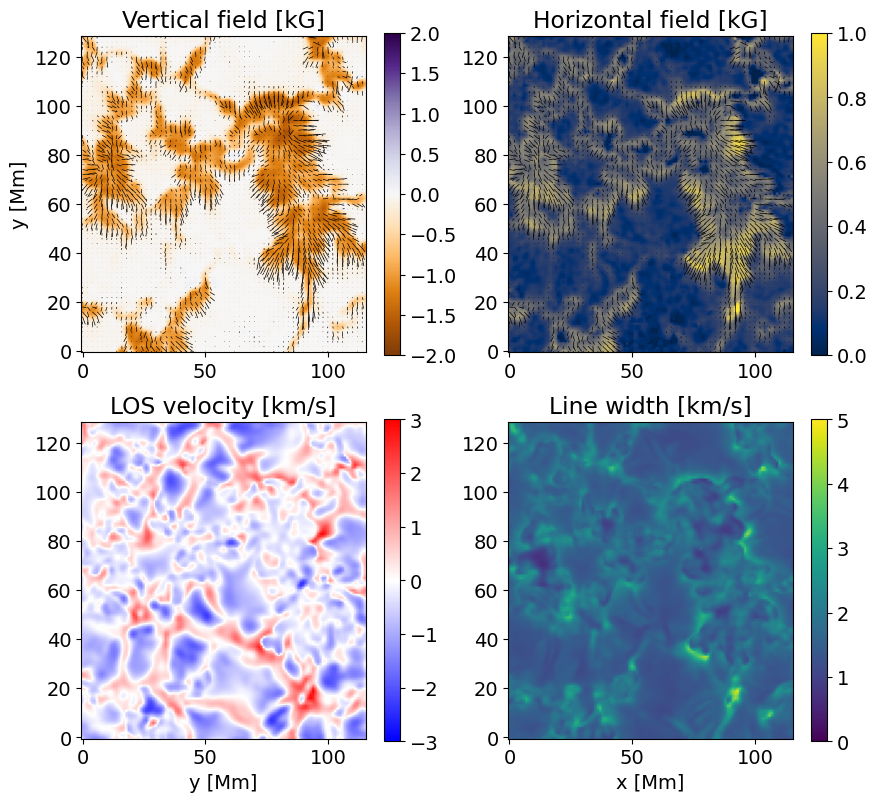

In [20]:
t = 60
plt.figure(figsize=[10.1,9.2])
plt.subplot(221)
plt.imshow((Bz[t].T/1E3), origin='lower', cmap='PuOr', vmin=-2, vmax=2)
plt.title("Vertical field [kG]")
#plt.imshow((cube[t,:,:,0].T), origin='lower', cmap='PuOr', vmin=-2000, vmax=2000)
plt.colorbar()
plt.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=15000, headwidth=0)
plt.ylabel("y [Mm]")

#plt.contour(I[t].T, [0.92], colors='white')
plt.subplot(222)
plt.title("Horizontal field [kG]")
plt.imshow((Bh[t].T/1E3), origin='lower', cmap='cividis', vmin=0, vmax=1)
#plt.imshow((cube[t,:,:,0].T), origin='lower', cmap='PuOr', vmin=-2000, vmax=2000)
plt.colorbar()
plt.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=15000, headwidth=0)
#plt.xlabel("x [Mm]")
#plt.contour(I[t].T, [0.92], colors='white')

plt.subplot(223)
plt.imshow(cube[t,:,:,3].T, origin='lower', cmap='bwr', vmin=-3,vmax=3)
plt.title("LOS velocity [km/s]")
plt.xlabel("x [Mm]")
plt.xlabel("y [Mm]")
plt.colorbar()

plt.subplot(224)
plt.imshow(cube[t,:,:,4].T/6300 * 3E5, origin='lower', cmap='viridis', vmin=0,vmax=5)
plt.title("Line width [km/s]")
plt.xlabel("x [Mm]")
plt.colorbar()

#plt.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=10000, headwidth=0)
#plt.contour(I[t].T, [0.92], colors='white')
#plt.subplot(133)
#plt.imshow(I[t].T, origin='lower', cmap='inferno', vmin=0.6,vmax=1.4)
#plt.colorbar()
#plt.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=10000, headwidth=0)
#plt.contour(I[t].T, [0.92], colors='white')

plt.savefig("overview.png", bbox_inches='tight')

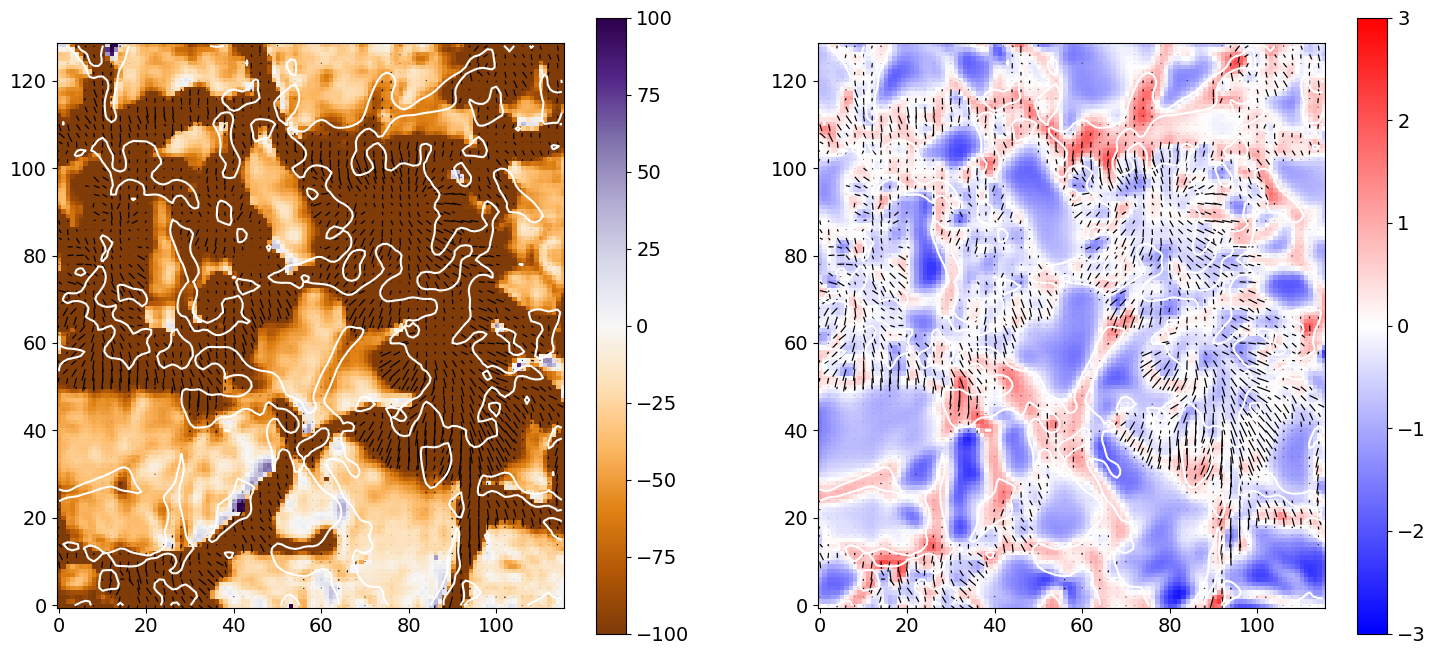

In [21]:
t = 123
plt.figure(figsize=[18,8])
plt.subplot(121)
plt.imshow((Bz[t].T), origin='lower', cmap='PuOr', vmin=-100, vmax=100)
#plt.imshow((cube[t,:,:,0].T), origin='lower', cmap='PuOr', vmin=-2000, vmax=2000)
plt.colorbar()
plt.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=20000, headwidth=0)
plt.contour(I[t].T, [0.92], colors='white')
plt.subplot(122)
plt.imshow(cube[t,:,:,3].T, origin='lower', cmap='bwr', vmin=-3,vmax=3)
plt.colorbar()
plt.quiver(X, Y, -Bxar[t].T, -Byar[t].T, scale=20000, headwidth=0)
plt.contour(I[t].T, [0.92], colors='white')
plt.savefig("bh_lines.png", bbox_inches='tight')

# STOKES PLOTS

In [22]:
t = 60
number = 102000 + 60 * 6000
path = '/home/milic/data/MiHi/6301_plage/obs04/mihi_sp/lr0250/'
stokes = fits.open(path+"img_fit."+str(number)+".."+str(number+5999)+".00.00.lr0250.cube.fits")[0].data

In [23]:
fits.open(path+"img_fit."+str(number)+".."+str(number+5999)+".00.00.lr0250.cube.fits")[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    4 / number of data axes                            
NAXIS1  =                  588 / length of data axis 1                          
NAXIS2  =                    4 / length of data axis 2                          
NAXIS3  =                  160 / length of data axis 3                          
NAXIS4  =                  147 / length of data axis 4                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
DATE    = '2024-03-14'         / Creation UTC (CCCC-MM-DD) date of FITS header  
NSR     =                    1 /                                                
WLI1    =                   

In [24]:
fits.open(path+"img_fit."+str(number)+".."+str(number+5999)+".00.00.lr0250.cube.fits")[1].data

array([6299.06      , 6299.07001704, 6299.08003407, 6299.09005111,
       6299.10006814, 6299.11008518, 6299.12010221, 6299.13011925,
       6299.14013629, 6299.15015332, 6299.16017036, 6299.17018739,
       6299.18020443, 6299.19022147, 6299.2002385 , 6299.21025554,
       6299.22027257, 6299.23028961, 6299.24030664, 6299.25032368,
       6299.26034072, 6299.27035775, 6299.28037479, 6299.29039182,
       6299.30040886, 6299.31042589, 6299.32044293, 6299.33045997,
       6299.340477  , 6299.35049404, 6299.36051107, 6299.37052811,
       6299.38054514, 6299.39056218, 6299.40057922, 6299.41059625,
       6299.42061329, 6299.43063032, 6299.44064736, 6299.4506644 ,
       6299.46068143, 6299.47069847, 6299.4807155 , 6299.49073254,
       6299.50074957, 6299.51076661, 6299.52078365, 6299.53080068,
       6299.54081772, 6299.55083475, 6299.56085179, 6299.57086882,
       6299.58088586, 6299.5909029 , 6299.60091993, 6299.61093697,
       6299.620954  , 6299.63097104, 6299.64098807, 6299.65100

In [25]:
stokes.shape

(147, 160, 4, 588)

In [26]:
stokes = stokes[16:-15,16:-15,:,200:400]
stokes.shape

(116, 129, 4, 200)

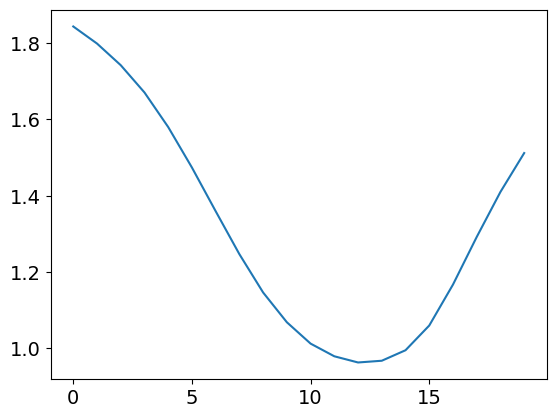

In [27]:
plt.plot(np.mean(stokes[:,:,0,130:150], axis=(0,1)))

In [28]:
Iqs = np.mean(stokes[:,:,0,100:125])

In [29]:
stokes /= Iqs

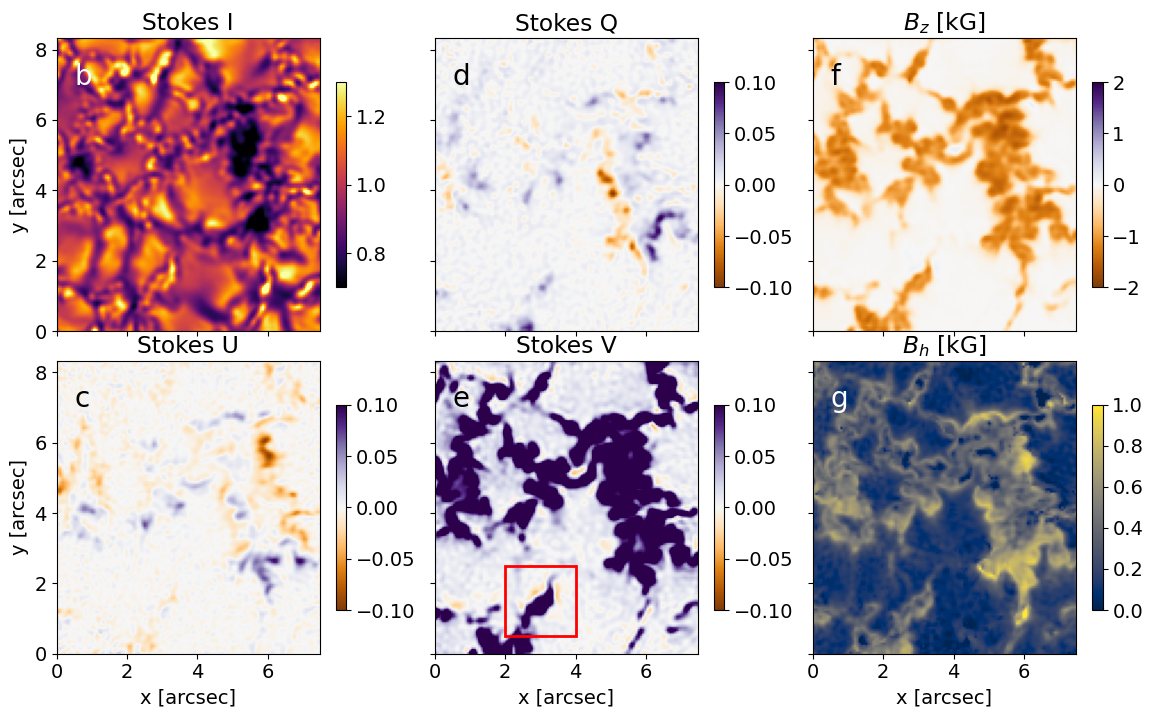

In [40]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=[14,8])

rect = patches.Rectangle((2, 0.5), 2, 2, linewidth=2, edgecolor='r', facecolor='none')


#divnorm = colors.TwoSlopeNorm(vmin=-1000, vcenter=0, vmax=200)

#subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(wspace=0.15, hspace=0.1)
plot_no = 0

for ax in axes.flat:
    
    if (plot_no==0):
        im = ax.imshow(np.mean(stokes[:,:,0,100:125],axis=2).T, origin='lower', cmap='inferno', vmin=0.7,vmax=1.3, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        ax.text(0.5,7.0,"b", color='white', fontsize=20)
        #ax.text(2200,2400,"t="+str(t*10)+"s", color='black', fontsize=20)
        #ax.set_xlim([500,3500])
        #ax.set_ylim([0,3000])
        ax.set_xticklabels([])
        
        ax.set_ylabel("y [arcsec]")
        ax.set_title("Stokes I")
        fig.colorbar(im, shrink=0.7)
    
    if (plot_no==1):
        im = ax.imshow(np.mean(stokes[:,:,2,140:145],axis=2).T, origin='lower', cmap='PuOr', vmin=-0.1,vmax=0.1, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        ax.text(0.5,7.0,"d", color='black', fontsize=20)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        ax.set_title("Stokes Q")
        fig.colorbar(im, shrink=0.7)
    
    if (plot_no==3):
        im = ax.imshow(np.mean(stokes[:,:,1,140:145],axis=2).T, origin='lower', cmap='PuOr', vmin=-0.1,vmax=0.1, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        #ax.set_yticklabels([])
        #ax.set_xticklabels([])
        ax.set_title("Stokes U")
        fig.colorbar(im, shrink=0.7)
        ax.text(0.5,7.0,"c", color='black', fontsize=20)
        ax.set_xlabel("x [arcsec]")
        ax.set_ylabel("y [arcsec]")
    
    
    if (plot_no==4):
        im = ax.imshow(np.mean(stokes[:,:,plot_no-1,147:152],axis=2).T, origin='lower', cmap='PuOr', vmin=-0.1,vmax=0.1, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        ax.set_yticklabels([])
        #ax.set_xticklabels([])
        ax.set_xlabel("x [arcsec]")
        ax.set_title("Stokes V")
        ax.text(0.5,7.0,"e", color='black', fontsize=20)
        ax.add_patch(rect)
        #ax.set_ylabel("y [km]")
        fig.colorbar(im, shrink=0.7)
        
    t = 60
    if (plot_no ==2):
        im = ax.imshow((Bz[t].T/1E3), origin='lower', cmap='PuOr', vmin=-2, vmax=2, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        ax.set_title("$B_{z}$ [kG]")
        fig.colorbar(im, shrink=0.7)
        ax.text(0.5,7.0,"f", color='black', fontsize=20)
        #ax.quiver(xa[::2], ya[::2], -Bxar[t].T, -Byar[t].T, scale=15000, headwidth=0)
        #ax.set_xlabel("x [km]")
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        
    if (plot_no ==5):
        im = ax.imshow((Bh[t].T/1E3), origin='lower', cmap='cividis', vmin=0, vmax=1, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        ax.set_title("$B_{h}$ [kG]")
        ax.text(0.5,7.0,"g", color='white', fontsize=20)
        #plt.title("Vertical field [kG]")
        fig.colorbar(im, shrink=0.7)
        #ax.quiver(xa[::2], ya[::2], -Bxar[t].T, -Byar[t].T, scale=15000, headwidth=0)
        ax.set_xlabel("x [arcsec]")
        ax.set_yticklabels([])
        
        
    plot_no+=1
    
#fig.subplots_adjust(right=0.9)
#cbar_ax = fig.add_axes([0.9, 0.15, 0.05, 0.7])
#fig.colorbar(im, cax=cbar_ax)
plt.savefig("obs_me_field.eps",bbox_inches='tight')
plt.savefig("obs_me_field.png",bbox_inches='tight')

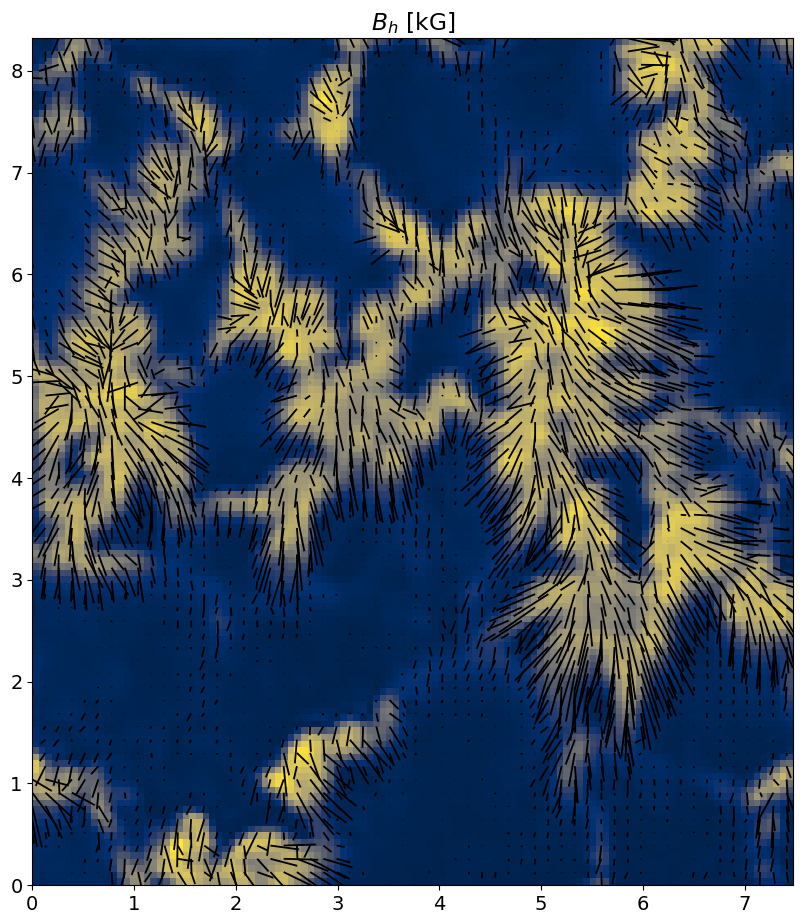

In [99]:
plt.figure(figsize=[12,11])
plt.imshow((np.abs(Bz[t].T/1E3)), origin='lower', cmap='cividis', vmin=0, vmax=1.5, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
plt.title("$B_{h}$ [kG]")
#plt.title("Vertical field [kG]")
plt.colorbar(im, shrink=0.7)
plt.quiver(xa[::2], ya[::2], -Bxar[t].T, -Byar[t].T, scale=10000, headwidth=0)
#ax.set_xlabel("x [arcsec]")
#ax.set_yticklabels([])

# NOW DEPTH-DEPENDENT THINGS (see the other notebook for more examples)

In [42]:
atmost = fits.open("/home/milic/data/scratch/test_tauu.fits")[0].data
print (atmost.shape)

(48, 10, 116, 129, 51)


In [61]:
bx = atmost[:,6,:,:,:]
by = atmost[:,7,:,:,:]


bxr = bx * np.cos(np.radians(15)) - by * np.sin(np.radians(15))
byr = by * np.cos(np.radians(15)) + bx * np.sin(np.radians(15))

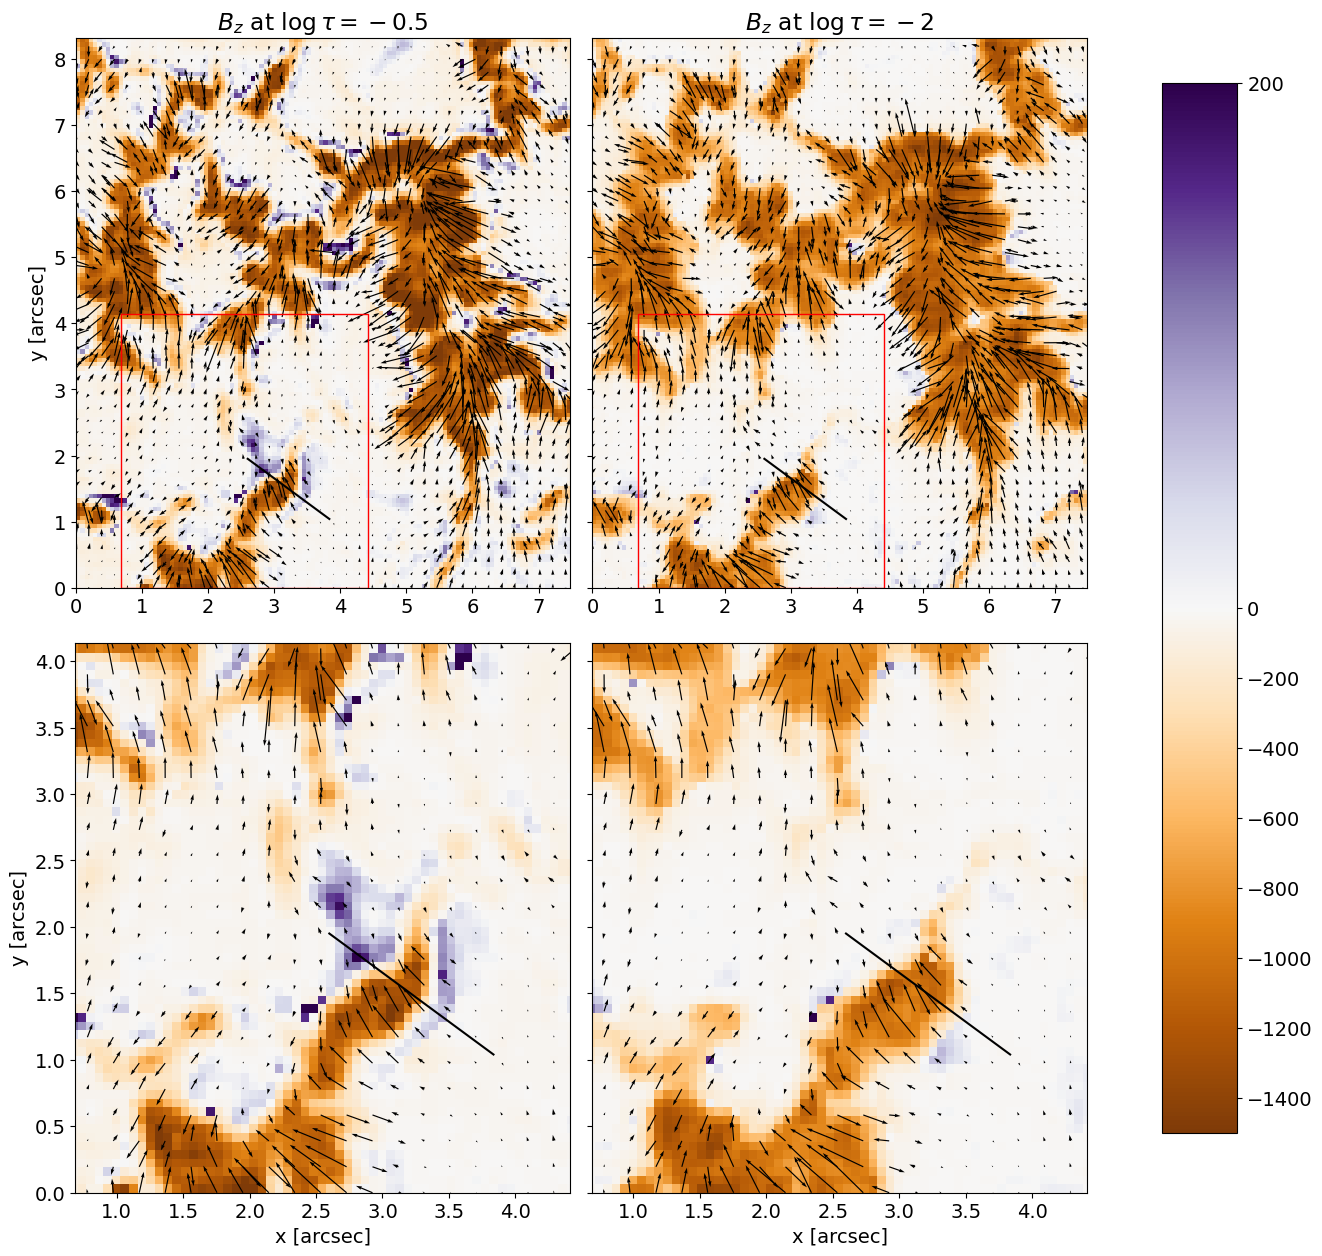

In [91]:
t = 20
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[15,15])

x1, y1 = [[2.6, 3.835],[1.95,1.04]]


divnorm = colors.TwoSlopeNorm(vmin=-1500, vcenter=0, vmax=200)

# Create a Rectangle patch
rect = patches.Rectangle((500/725.0, 0), 2700./725.0, 3000./725.0, linewidth=1, edgecolor='r', facecolor='none')
#rect = patches.Rectangle((500/48.0, 3000/48.0), 2700./48.0, 3000./48.0, linewidth=1, edgecolor='r', facecolor='none')

image_no = 0

d1 = 15
d2 = 30

#subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(wspace=-0.2, hspace=0.1)
for ax in axes.flat:
    
    if (image_no == 0):
        im=ax.imshow(atmost[t,8,:,:,d1].T, origin='lower', cmap='PuOr', norm=divnorm, extent = [xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        #ax.set_xticklabels([])
        #ax.set_xlabel("x [arcsec]")
        ax.quiver(xa[::3], ya[::3], bx[t,::3,::3,d1].T, by[t,::3,::3,d1].T, scale=10000, headwidth=3)
        ax.set_ylabel("y [arcsec]")
        ax.set_title("$B_z$ at $\\log\\tau=-0.5$")
        rc = copy(rect)
        ax.add_patch(rc)
        ax.plot(x1,y1,color='black',linewidth=1.5)
        #ax.hlines(1.8, 0, xa[-1], colors='pink')
    #ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
        
    
    #im = ax.imshow((Bz[t].T), origin='lower', cmap='PuOr', norm=divnorm, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
    #ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
    #ax.set_xlim([500/725.0,3500/725.0])
    #ax.set_ylim([0/725.0,3000/725.0])
    
    if (image_no == 1):
        im=ax.imshow(atmost[t,8,:,:,d2].T, origin='lower', cmap='PuOr', norm=divnorm, extent = [xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        ax.quiver(xa[::3], ya[::3], bxr[t,::3,::3,d2].T, byr[t,::3,::3,d2].T, scale=10000, headwidth=3)
        
        ax.set_yticklabels([])
        #ax.set_xlabel("x [arcsec]")
        rc = copy(rect)
        ax.add_patch(rc)
        #ax.hlines(1.8, 0, xa[-1], colors='pink')
        ax.set_title("$B_z$ at $\\log\\tau=-2$")
        ax.plot(x1,y1,color='black',linewidth=1.5)
        #ax.add_patch(rect)
        
        
    
    if (image_no ==2):
        im=ax.imshow(atmost[t,8,:,:,d1].T, origin='lower', cmap='PuOr', norm=divnorm, extent = [xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        ax.quiver(xa[::3], ya[::3], bxr[t,::3,::3,d1].T, byr[t,::3,::3,d1].T, scale=7000, headwidth=3)
        #ax.set_yticklabels([])
        ax.set_xlabel("x [arcsec]")
        ax.set_ylabel("y [arcsec]")
        #ax.hlines(1.8, 0, 5, colors='pink')
        ax.set_xlim([500/725.0,3200/725.0])
        ax.set_ylim([0/725.0,3000/725.0])
        ax.plot(x1,y1,color='black',linewidth=1.5)
    #ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
        
    
    #im = ax.imshow((Bz[t].T), origin='lower', cmap='PuOr', norm=divnorm, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
    #ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
    #ax.set_xlim([500/725.0,3500/725.0])
    #ax.set_ylim([0/725.0,3000/725.0])
    
    if (image_no == 3):
        im=ax.imshow(atmost[t,8,:,:,d2].T, origin='lower', cmap='PuOr', norm=divnorm, extent = [xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
        ax.quiver(xa[::3], ya[::3], bxr[t,::3,::3,d2].T, byr[t,::3,::3,d2].T, scale=7000, headwidth=3)
        ax.set_yticklabels([])
        ax.set_xlabel("x [arcsec]")
        ax.plot(x1,y1,color='black',linewidth=1.5)
        #ax.hlines(1.8, 0, 5, colors='pink')
        ax.set_xlim([500/725.0,3200/725.0])
        ax.set_ylim([0/725.0,3000/725.0])
        
        
    image_no +=1
    

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.9, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.savefig("firtez_2_tau_h.eps",bbox_inches='tight')
plt.savefig("firtez_2_tau_h.png",bbox_inches='tight')

In [44]:
np.argmin(np.abs(ya-1.8))

28

In [41]:
atmos = fits.open("/home/milic/data/scratch/test.fits")[0].data
print (atmos.shape)

(48, 9, 116, 129, 64)


In [42]:
zmean = np.mean(atmost[:,-1,:,:,10])
print (zmean)

202.45665902365033


In [51]:
zimean = np.mean(atmost[0,-1,:,:,:], axis=(0,1)) - zmean
zimean

array([-47.62882075, -43.45189453, -39.3142552 , -35.15926171,
       -30.93544904, -26.58483477, -22.02911561, -17.16503373,
       -11.88419837,  -5.99754594,   0.71957825,   8.41463387,
        16.90619472,  25.96333442,  35.4957501 ,  45.44298623,
        55.70739414,  66.14099959,  76.61164826,  87.08252446,
        97.60518926, 108.2176957 , 118.90028967, 129.61738397,
       140.32977841, 151.00892723, 161.64770931, 172.2709332 ,
       182.93201713, 193.67261529, 204.50348677, 215.39180165,
       226.28202102, 237.13373782, 247.89340347, 258.51787706,
       269.00504154, 279.39596729, 289.72925302, 299.97388592,
       310.0411906 , 319.83173954, 329.25591122, 338.26347694,
       346.85034367, 355.07659337, 363.0454292 , 370.87082511,
       378.64456949, 386.40380874, 394.15400167])

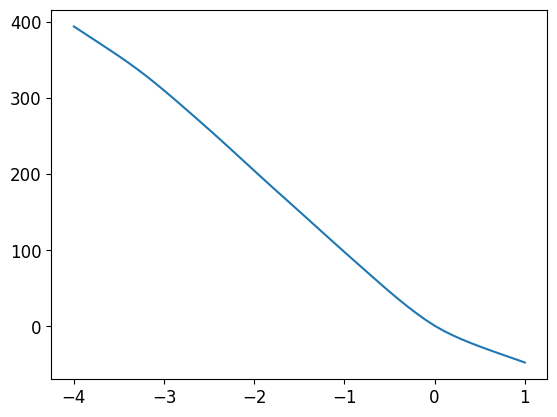

In [52]:
plt.plot(atmost[0,0,0,0,:], zimean)

In [56]:
zimean[15] - zimean[30]

-159.06050054225926

In [43]:
z = np.arange(atmos.shape[-1]) * 12.0 - zmean

In [44]:
font = {'size'   : 12}

matplotlib.rc('font', **font)

In [45]:
bh = np.sqrt(atmos[:,6,:,:,:]**2.0 + atmos[:,7,:,:,:]**2.0)

In [46]:
XX,ZZ = np.meshgrid(x[::1],z[::1])

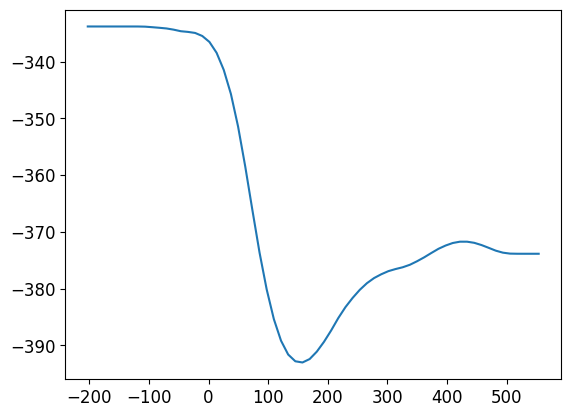

In [53]:
plt.plot(z, np.mean(atmos[0,8,:,:,:], axis=(0,1)))

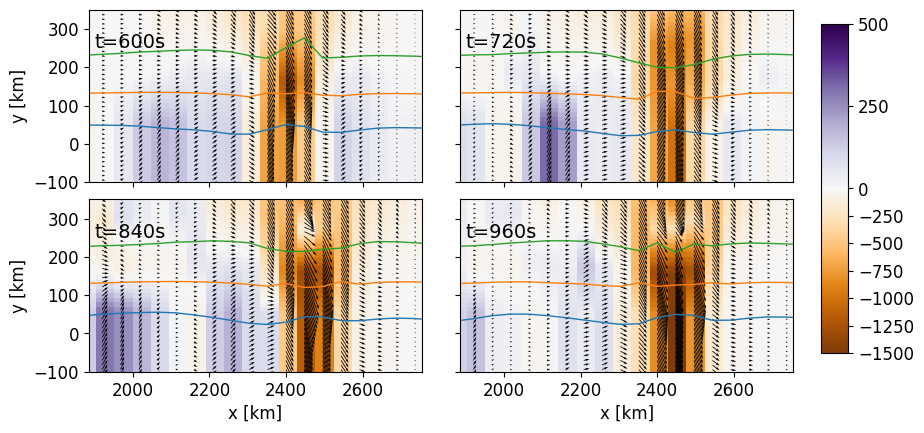

In [47]:
t = 20
step = 4
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[9,4.7])


divnorm = colors.TwoSlopeNorm(vmin=-1500, vcenter=0, vmax=500)

#subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(wspace=0, hspace=0.1)
for ax in axes.flat:
    
    #im = ax.imshow((Bz[t].T), origin='lower', cmap='PuOr', norm=divnorm, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
    im = ax.imshow(atmos[t,8,:,28,:].T, origin='lower', cmap='PuOr', norm=divnorm, extent = [x[0],x[-1],z[0],z[-1]])
    ax.quiver(XX, ZZ, bh[t,::1,28,::1].T, atmos[t,8,::1,28,::1].T,scale=10000)
    ax.text(1900.0,250.0,"t="+str(t*30)+"s", color='black', fontsize=14)
    ax.plot(x, atmost[t,-1,:,28,10].T-zmean,linewidth=1)
    ax.plot(x, atmost[t,-1,:,28,20].T-zmean,linewidth=1)
    ax.plot(x, atmost[t,-1,:,28,30].T-zmean,linewidth=1)
    ax.set_xlim([2.6*725.0, 3.8*725.0])
    ax.set_ylim([-100.0,350.0])
    
    
    if (t==20):
        ax.set_xticklabels([])
        ax.set_ylabel("y [km]")
    
    if (t==20+step):
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        
    if (t==20+2*step):
        ax.set_xlabel("x [km]")
        ax.set_ylabel("y [km]")
    if (t==20+3*step):
        ax.set_yticklabels([])
        ax.set_xlabel("x [km]")
    
    t += 4

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.savefig("zoom_in_vertical.eps",bbox_inches='tight')
plt.savefig("zoom_in_vertical.png",bbox_inches='tight')

In [104]:
#plt.imshow(atmos[0,8,:,28,:].T, origin='lower', cmap='PuOr', vmin=-1500, vmax=1500, extent = [y[0],y[-1],z[0],z[-1]])

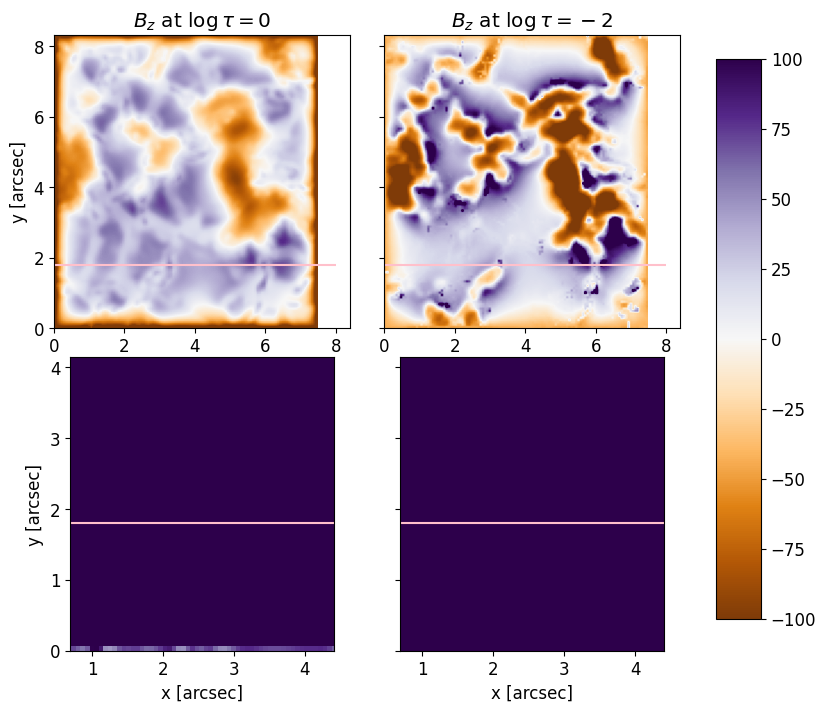

In [131]:
t = 20
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[9,8])


divnorm = colors.TwoSlopeNorm(vmin=-100, vcenter=0, vmax=100)

image_no = 0

#subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
fig.subplots_adjust(wspace=-0.1, hspace=0.1)
for ax in axes.flat:
    
    if (image_no == 0):
        im=ax.imshow(atmost[t,-1,:,:,10].T - np.mean(atmost[t,-1,:,:,10].T), origin='lower', cmap='PuOr', norm=divnorm, extent = [xa[0],xa[-1],ya[0],ya[-1]])
        #ax.set_xticklabels([])
        #ax.set_xlabel("x [arcsec]")
        ax.set_ylabel("y [arcsec]")
        ax.set_title("$B_z$ at $\\log\\tau=0$")
        ax.hlines(1.8, 0, 8, colors='pink')
    #ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
        
    
    #im = ax.imshow((Bz[t].T), origin='lower', cmap='PuOr', norm=divnorm, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
    #ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
    #ax.set_xlim([500/725.0,3500/725.0])
    #ax.set_ylim([0/725.0,3000/725.0])
    
    if (image_no == 1):
        im=ax.imshow(atmost[t,-1,:,:,30].T - np.mean(atmost[t,-1,:,:,30].T), origin='lower', cmap='PuOr', norm=divnorm, extent = [xa[0],xa[-1],ya[0],ya[-1]])
        ax.set_yticklabels([])
        #ax.set_xlabel("x [arcsec]")
        ax.set_title("$B_z$ at $\\log\\tau=-2$")
        ax.hlines(1.8, 0, 8, colors='pink')
        
    
    if (image_no ==2):
        im=ax.imshow(atmost[t,-1,:,:,10].T, origin='lower', cmap='PuOr', norm=divnorm, extent = [xa[0],xa[-1],ya[0],ya[-1]])
        #ax.set_yticklabels([])
        ax.set_xlabel("x [arcsec]")
        ax.set_ylabel("y [arcsec]")
        ax.hlines(1.8, 0, 5, colors='pink')
        ax.set_xlim([500/725.0,3200/725.0])
        ax.set_ylim([0/725.0,3000/725.0])
    #ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
        
    
    #im = ax.imshow((Bz[t].T), origin='lower', cmap='PuOr', norm=divnorm, extent=[xa[0],xa[-1],ya[0],ya[-1]], aspect='equal')
    #ax.text(2200/725.0,2400/725.0,"t="+str(t*10)+"s", color='black', fontsize=20)
    #ax.set_xlim([500/725.0,3500/725.0])
    #ax.set_ylim([0/725.0,3000/725.0])
    
    if (image_no == 3):
        im=ax.imshow(atmost[t,-1,:,:,30].T, origin='lower', cmap='PuOr', norm=divnorm, extent = [xa[0],xa[-1],ya[0],ya[-1]])
        ax.set_yticklabels([])
        ax.set_xlabel("x [arcsec]")
        ax.hlines(1.8, 0, 5, colors='pink')
        ax.set_xlim([500/725.0,3200/725.0])
        ax.set_ylim([0/725.0,3000/725.0])
        
        
    image_no +=1
    

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.9, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.savefig("firtez_2_tauz.eps",bbox_inches='tight')
plt.savefig("firtez_2_tauz.png",bbox_inches='tight')

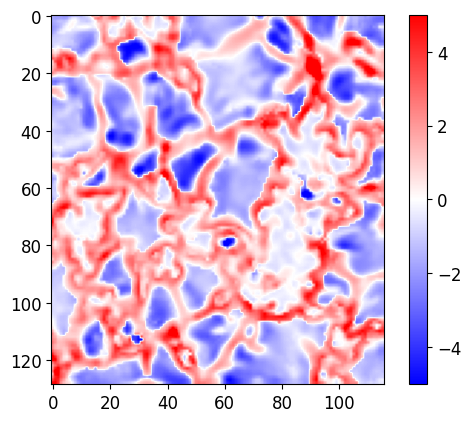

In [66]:
plt.imshow(atmost[t,5,:,:,10].T/1E5,cmap='bwr',vmin=-5,vmax=5)
plt.colorbar()

In [41]:
import firtez_dz as frz

In [42]:
font = {'size'   : 14}

matplotlib.rc('font', **font)

In [43]:
atm_test = frz.read_model("/home/milic/data/scratch/out_hsra_nx116_ny129_nz64_dz12_new.bin")

In [44]:
err_test = frz.read_model("/home/milic/data/scratch/eout_hsra_nx116_ny129_nz64_dz12_new.bin")

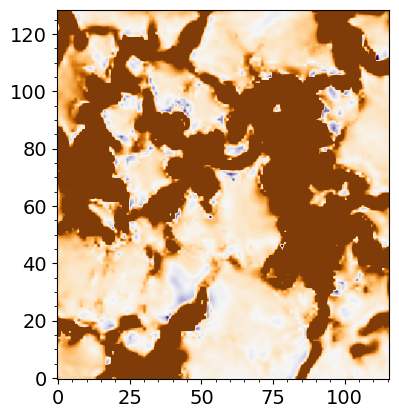

In [54]:
plt.imshow(atm_test.bz[:,:,22].T, origin='lower', cmap='PuOr', vmin=-200, vmax=200)

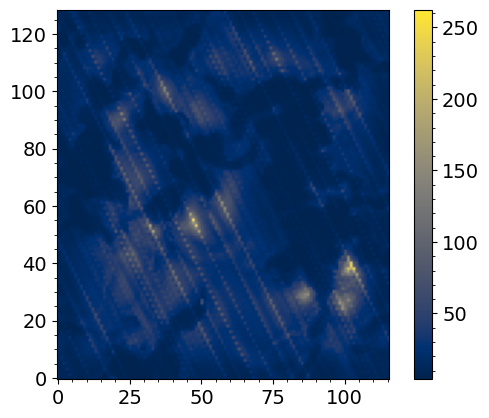

In [55]:
plt.imshow(err_test.bz[:,:,22].T, origin='lower', cmap='cividis')
plt.colorbar()

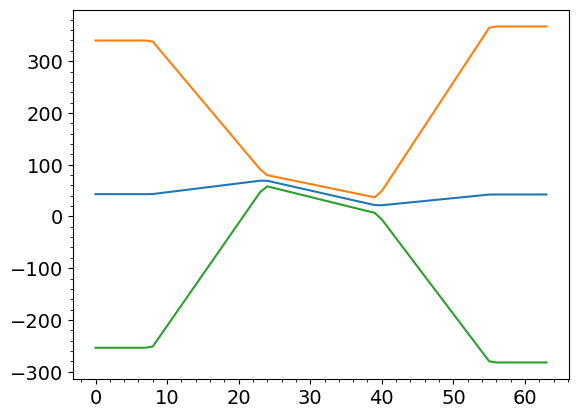

In [53]:
plt.plot(atm_test.bz[42,27,:])
plt.plot(atm_test.bz[42,27,:]+err_test.bz[42,27,:])
plt.plot(atm_test.bz[42,27,:]-err_test.bz[42,27,:])

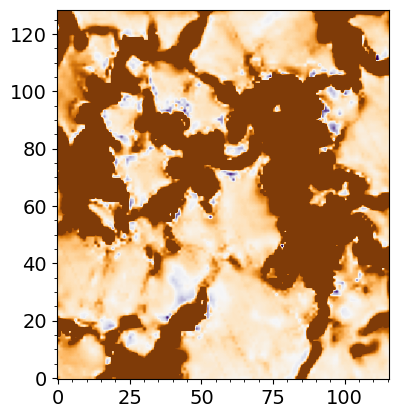

In [64]:
plt.imshow(atm_test.bz[:,:,24].T - err_test.bz[:,:,24].T, origin='lower', cmap='PuOr', vmin=-200, vmax=200)